# 퍼셉트론

-	다수의 신호를 입력으로 받아 하나의 신호를 출력
-	신호: 전류나 강물처럼 흐름이 있는 것, 퍼셉트론 신호는 ‘흐른다/안 흐른다(0 or 1)’의 두 가지 값을 가질 수 있음

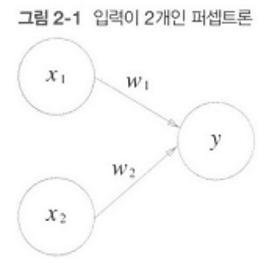

x1, x2: 입력 신호

y: 출력 신호

w1, w2: 가중치

뉴런(노드): 그림의 원

입력 신호가 뉴런에 보내질 때는 각각 고유한 가중치가 곱해짐

뉴런에서 보내온 신호의 총합이 정해진 한계(임계값 θ)을 넘어설 때만 1을 출력

-	퍼셉트론의 동작을 수식으로 표현

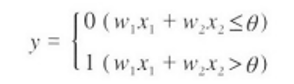

퍼셉트론은 복수의 입력 신호 각각에 고유한 가중치를 부여함

가중치는 각 신호가 결과에 주는 영향력을 조정하는 요소로 작용

->	가중치가 클수록 해당 신호가 더 중요


## 단순한 논리 회로

AND 게이트

-	입력이 둘이고 출력은 하나
-	AND 게이트 진리표(입력 신호와 출력 신호의 대응 표)  
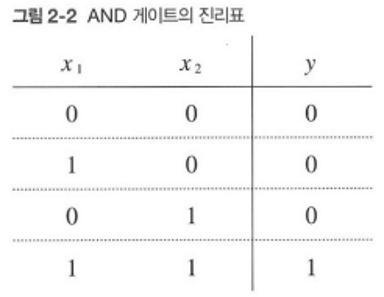

-	퍼셉트론으로 표현하려면 진리표대로 작동하도록 하는 (w1, w2, θ)의 값을 정해야함
-	(w1, w2, θ)가 (0.5, 0.5, 0.7), (0.5, 0.5, 0.8), (1.0, 1.0, 1.0)일 때 모두 AND 게이트의 조건을 만족함
-	매개변수를 이렇게 설정하면 x1과 x2 모두가 1일 때만 가중 신호의 총합이 주어진 임계값을 넘게 됨

NAND 게이트, OR 게이트
-	NAND는 Not AND를 의미하며, 동작은 AND 게이트의 출력을 뒤집은 것이 됨
-	NAND 게이트 진리표  
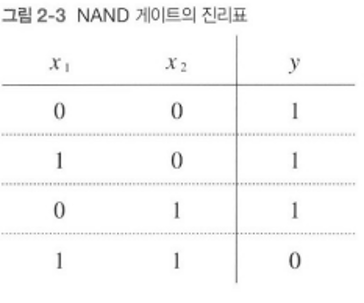
 
-	x1과 x2가 모두 1일 때만 0을 출력, 나머지는 1 출력
-	이를 만족하는 조합: (-0.5, -0.5, 0.7) -> x1과 x2가 둘 다 1일 때만 임계값을 넘지 못함
-	NAND 게이트는 AND 게이트의 매개변수의 부호를 모두 반전하면 됨

-	OR 게이트는 입력 신호 중 하나 이상이 1이면 출력이 1이 됨
-	OR 게이트 진리표  
 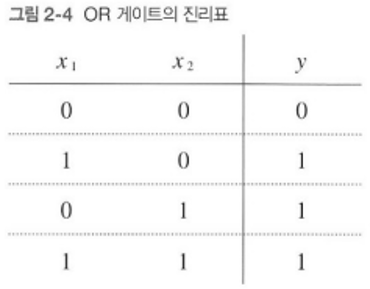

-	이를 만족하는 조합: (0.5, 0.5, -0.2) -> x1과 x2가 둘 다 0일 때만 임계값을 넘지 못함


## 퍼셉트론 구현

In [2]:
# 간단한 구현 (AND 게이트)
def AND(x1, x2):
    w1, w2, theta = 0.5, 0.5, 0.7
    tmp = x1*w1 + x2*w2
    if tmp <= theta:  # 총합이 임계값을 넘지 못함
        return 0
    elif tmp > theta:  # 총합이 임계값을 넘음
        return 1

print(AND(0, 0))
print(AND(1, 0))
print(AND(0, 1))
print(AND(1, 1))

0
0
0
1


### 가중치와 편향 도입

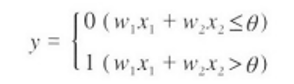


-	위의 원래 식에서 θ를 -b로 치환하면 퍼셉트로 동작이 아래처럼 됨 

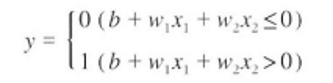

-	이때 b를 편향이라 함, w1,w2는 그대로 가중치
-	-> 여기서 퍼셉트론은 입력 신호에 가중치를 곱한 값과 편향을 합한 값이 0을 넘으면 1 출력, 넘지 않으면 0 출력


In [3]:
# 가중치와 편향 도입
import numpy as np

x = np.array([0, 1])  # 입력
w = np.array([0.5, 0.5])  # 가중치
b = -0.7  # 편향

print(w * x)  # 각 입력 신호에 가중치 곱함
print(np.sum(w * x))  # 총합
print(np.sum(w * x) + b)  # 총합에 편향을 더한 값

[0.  0.5]
0.5
-0.19999999999999996


-	이전의 AND에서 theta가 -b가 됨
-	편향은 가중치 w1, w2와 기능이 다름
    -	w1, w2는 각 입력 신호가 결과에 주는 영향력(중요도)을 조절하는 매개변수
    -	편향은 뉴런이 얼마나 쉽게 활성화(1 출력)할 지를 조정하는 매개변수
-	NAND, OR은 AND와 같은 구조이고 가중치와 편향의 매개변수 값만 다름
-	NAND 게이트


In [4]:
# 가중치와 편향 구현하기

# 가중치와 편향을 도입한 AND 게이트
def AND(x1, x2):
    x = np.array([x1, x2])
    w = np.array([0.5, 0.5])
    b = -0.7

    tmp = np.sum(w * x) + b
    if tmp <= 0:
        return 0
    if tmp > 0:
        return 1

# NAND 게이트
def NAND(x1, x2):
    x = np.array([x1, x2])
    w = np.array([-0.5, -0.5])  # AND와 가중치, 편향만 다름
    b = 0.7

    tmp = np.sum(w * x) + b
    if tmp <= 0:
        return 0
    else:
        return 1

# OR 게이트
def OR(x1, x2):
    x = np.array([x1, x2])
    w = np.array([0.5, 0.5])  # AND와 가중치, 편향만 다름
    b = -0.2

    tmp = np.sum(w * x) + b
    if tmp <= 0:
        return 0
    else:
        return 1

## 퍼셉트론의 한계

-	XOR 게이트 (배타적 논리합): x1, x2 중 한쪽이 1일 때만 1 출력
-	XOR 게이트 진리표  
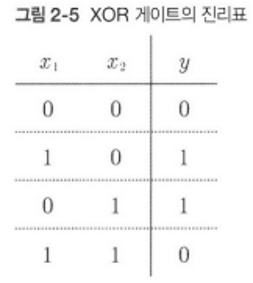
-	지금까지의 퍼셉트론으로는 구현할 수 없음
-	OR 게이트와 비교
    -	OR 게이트는 매개변수가 (b, w1, w2) = (-0.5, 1.0, 1.0)일 때 만족  
 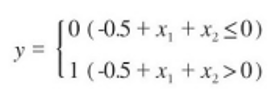
    -	위 식의 퍼셉트론은 직선으로 나뉜 두 영역을 만듦  
 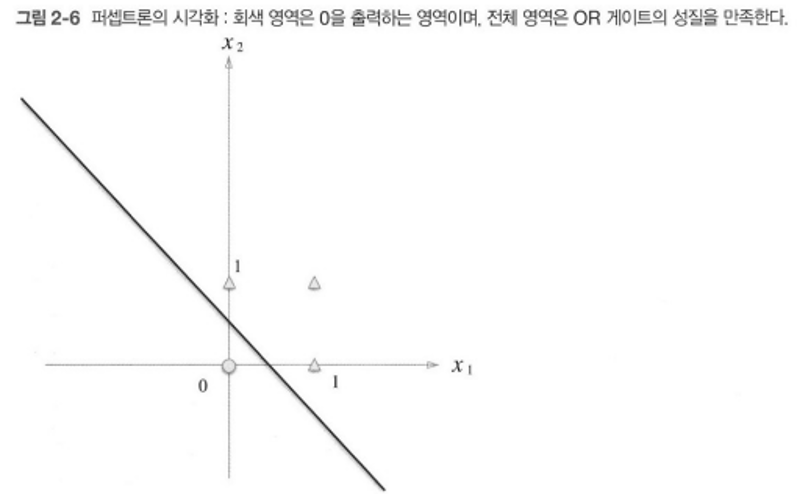
    -	직선으로 나뉜 한쪽 영역은 1을 출력, 다른 한쪽은 0을 출력
    -	OR 게이트는 x1, x2가 (0,0)일 때만 0을 출력하고, (0,1), 1,0), 1,1)일 때는 1을 출력함 – 그림에서 각각 O와 △로 표시
    -	OR 게이트를 만들기 위해서는 O와 △를 직선으로 나누면 됨
-	XOR 게이트의 경우  
 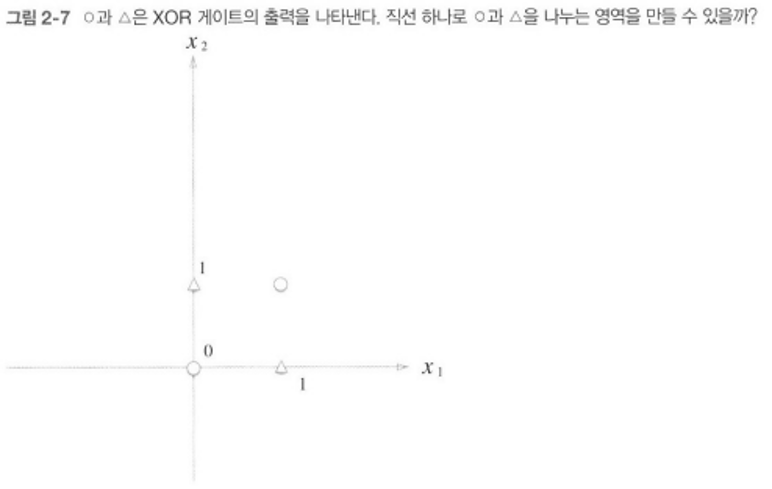
    -	XOR 게이트는 O와 △를 직선 하나로 나누는 것이 불가능
    -	-> 곡선이라면 나누는 것이 가능  
 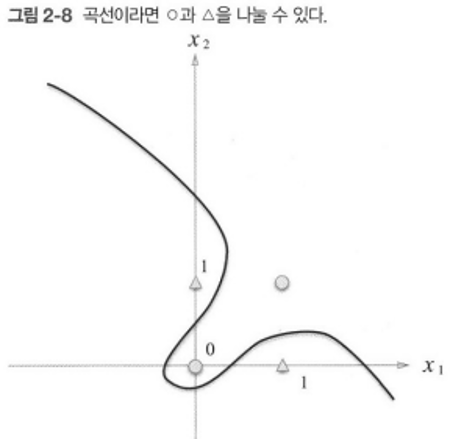
    -	퍼셉트론은 직선 하나로 나눈 영역만 표현할 수 있다는 한계가 있음
    -	== 곡선을 표현할 수 없음
    -	비선형 영역: 그림 2-8과 같은 곡선의 영역 (비선형: 기계학습에서 자주 쓰임)
    -	선형 영역: 직선의 영역


## 다층 퍼셉트론

퍼셉트론은 층을 쌓아서 다층 퍼셉트론을 만들 수 있음

층을 하나 더 쌓아서 XOR 만들기
-	기존 게이트 조합하기
    -	앞서 만든 AND, NAND, OR 게이트를 조합
    -	위 세가지를 기호로 표현 (NAND의 O기호는 출력을 반전하는 것)  
 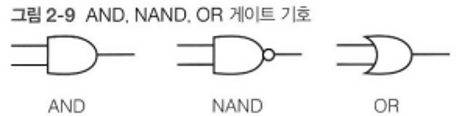  
 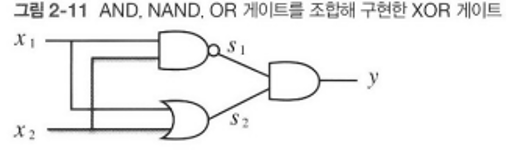
    -	위 그림처럼 조합하면 XOR 게이트를 구현할 수 있음
    -	x1, z2는 NAND와 OR 게이트의 입력이 되고, NAND와 OR의 출력이 AND 게이트의 입력으로 이어짐
    -	진리표를 통해 보기 (s1: NAND 출력, s2: OR 출력)  
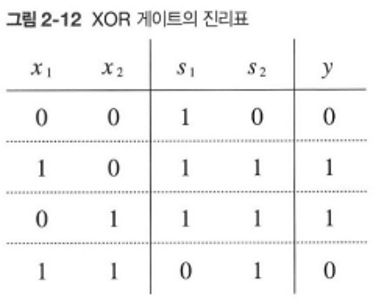

In [ ]:
# XOR 게이트 구현하기
def XOR(x1, x2):
    s1 = NAND(x1, x2)
    s2 = OR(x1, x2)
    y = AND(s1, s2)
    return y

print(XOR(0, 0))
print(XOR(1, 0))
print(XOR(0, 1))
print(XOR(1, 1))

0
1
1
0


-	지금 구현한 XOR을 뉴런을 이용한 퍼셉트론으로 표현  
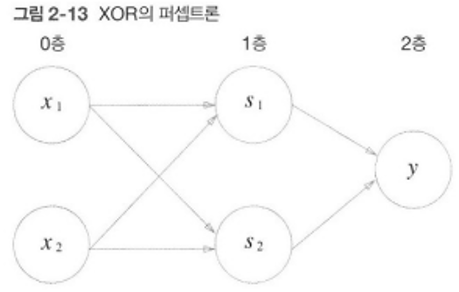
-	XOR은 다층 구조의 네트워크
-	왼쪽부터 차례로 0, 1, 2층 - XOR는 2층 퍼셉트론
-	총 3층으로 구성되지만 가중치를 갖는 층은 2개 (0층과 1층 사이, 1층과 2층 사이)이기 때문에 2층 퍼셉트론으로 부름 - 문헌에 따라 구성 층을 기준으로 하여 3층 퍼셉트론이라 부르는 경우도 있음
-	다층 퍼셉트론: 층이 여러 개인 퍼셉트론
-	그림과 같이 2층 퍼셉트론에서는 0층에서 1층으로, 1층에서 2층으로 신호가 전달되는 동작
    1.	0층의 두 뉴런이 입력 신호를 받아 1층의 뉴런으로 신호를 보냄
    2.	1층의 뉴런이 2층의 뉴런으로 신호를 보내고, 2층의 뉴런은 y를 출력
-	단층 퍼셉트론으로 표현하지 못한 것을 층을 하나 늘려 구현할 수 있게 됨
-	-> 퍼셉트론은 층을 쌓아(깊게 하여) 더 다양한 것을 표현 가능


## NAND에서 컴퓨터까지

다층 퍼셉트론으로 만들 수 있는 것들
-	덧셈을 처리하는 가산기
-	2진수를 10진수로 변환하는 인코더
-	어떤 조건을 충족하면 1을 출력하는 회로(패리티 검사 회로)
-	컴퓨터까지 표현 가능

컴퓨터는 정보를 처리하는 기계
-	무언가 입력하면 정해진 방법으로 처리 후 그 결과를 출력함
-	-> 컴퓨터도 퍼셉트론처럼 입력과 출력으로 구성된 특정 규칙대로 계산을 수행

NAND 게이트의 조합만으로 컴퓨터를 표현 가능 == 퍼셉트론으로 표현 가능
“이론상 2층 퍼셉트론이면 컴퓨터를 만들 수 있다”

-	2층 퍼셉트론 - 비선형인 시그모이드 함수를 활성화 함수로 이용하면 임의의 함수를 표현할 수 있다는 사실이 증명되었음 (3장 참고)
하지만 2층 퍼셉트론 구조에서 가중치를 적절히 설정하여 컴퓨터를 만드는 것은 어려움

    ->	NAND 등의 저수준 소자에서 시작해 컴퓨터를 만드는 데 필요한 부붐(모듈)을 단계적으로 만들어 감

    즉, 처음에는 AND와 OR 게이트, 그 다음에는 반가산기와 전가산기, 그 다음에 ALU, 그 다음에 CPU라는 방법
    
    그래서 퍼셉트론으로 표현하는 컴퓨터도 여러 층을 다시 층층이 겹친 구조로 만드는 방향이 자연스러움
    
    책에서 컴퓨터를 만들진 않지만 퍼셉트론은 층을 거듭 쌓으면 비선형적인 표현도 가능하고, 이론상 컴퓨터가 수행하는 처리도 모두 표현할 수 있다는 것을 기억하면 됨


정리
-	퍼셉트론은 입출력을 가진 갖춘 알고리즘이다. 입력을 주면 정해진 규칙에 따른 값을 출력한다.
-	퍼셉트론에서는 ‘가중치’와 ‘편향’을 매개변수로 설정한다.
-	퍼셉트론으로 AND, OR 게이트 등의 논리 회로를 표현할 수 있다.
-	XOR 게이트는 단층 퍼셉트론으로는 표현할 수 없다.
-	2층 퍼셉트론을 이용하면 XOR 게이트를 표현할 수 있다.
-	단층 퍼셉트론은 직선형 영역만 표현할 수 있고, 다층 퍼셉트론은 비선형 영역도 표현할 수 있다.
-	다층 퍼셉트론은 (이론상) 컴퓨터를 만들 수 있다.
